In [1]:
import pandas as pd
import numpy as np


In [3]:
import pandas as pd

data = {
    "Age": [
        19, 35, 26, 27, 19,
        25, 46, 48, 45, 34,
        67, 27, 32, 25, 38,
        41, 42, 48, 29, 35
    ],

    "EstimatedSalary": [
        19000, 20000, 43000, 57000, 76000,
        33000, 82000, 90000, 110000, 72000,
        150000, 52000, 85000, 30000, 60000,
        87000, 79000, 95000, 43000, 65000
    ],

    "Purchased": [
        0, 0, 0, 0, 0,
        0, 1, 1, 1, 1,
        1, 0, 1, 0, 1,
        1, 1, 1, 0, 1
    ]
}

df = pd.DataFrame(data)

df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,25,33000,0
6,46,82000,1
7,48,90000,1
8,45,110000,1
9,34,72000,1


In [8]:
import seaborn as sns
import matplotlib.pyplot  as plt

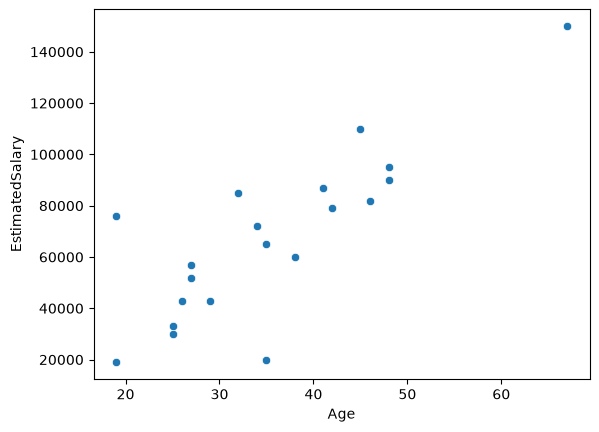

In [9]:
sns.scatterplot(
    x=df.iloc[:, 0],    # Age
    y=df.iloc[:, 1]     # EstimatedSalary
)

plt.show()

In [10]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [18]:
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [19]:
model = Sequential()
model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [22]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3750 - loss: 805.1093 - val_accuracy: 0.7500 - val_loss: 53.9587
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.3750 - loss: 141.2258 - val_accuracy: 0.2500 - val_loss: 324.4249
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6250 - loss: 138.1433 - val_accuracy: 0.2500 - val_loss: 589.1702
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.6250 - loss: 250.8625 - val_accuracy: 0.2500 - val_loss: 759.0409
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6250 - loss: 323.1862 - val_accuracy: 0.2500 - val_loss: 860.1498
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6250 - loss: 366.2327 - val_accuracy: 0.2500 - val_loss: 908.0646
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6250 - loss: 386.6307 - val_accuracy: 0.2500 - val_loss: 913.1089
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6250 - loss: 388.7756 

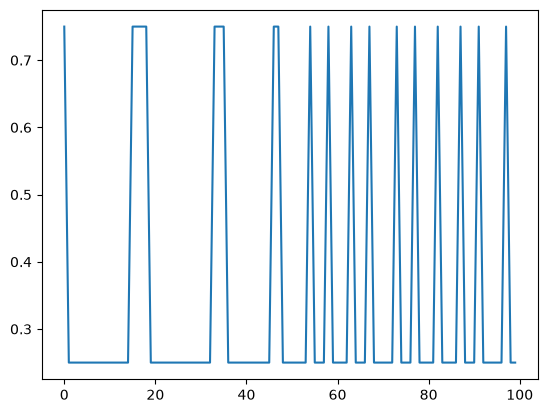

In [23]:
plt.plot(history.history['val_accuracy'])

# Applying scaling

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_scaled

array([[-0.36922879,  0.05277717],
       [-1.18721258, -1.16696198],
       [-1.00543841, -0.41635327],
       [ 2.6300451 ,  2.49225547],
       [-0.27834171, -1.57354169],
       [ 0.90319043,  0.77211052],
       [ 0.90319043,  0.61573371],
       [ 0.35786791,  0.27170471],
       [-0.00568044, -0.32252718],
       [-1.0963255 , -0.85420835],
       [-1.00543841, -0.57273008],
       [ 0.72141626,  0.3655308 ],
       [-0.27834171, -0.16615036],
       [-1.18721258, -1.26078806],
       [ 0.26698082,  0.52190762],
       [ 0.63052917,  1.24124096]])

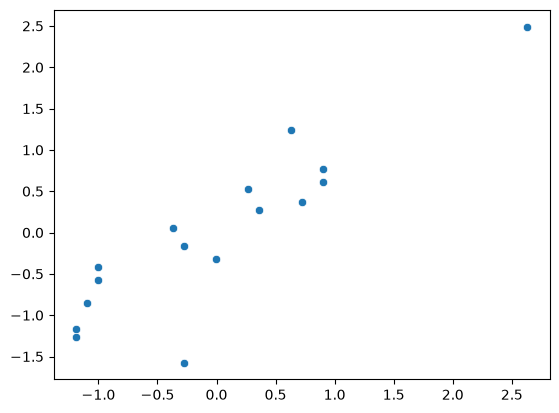

In [27]:
sns.scatterplot(
    x=X_train_scaled[:, 0],   # Scaled Age
    y=X_train_scaled[:, 1]    # Scaled EstimatedSalary
)

plt.show()

In [28]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100
)

Epoch 1/100


e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step - accuracy: 0.3750 - loss: 0.6881 - val_accuracy: 0.7500 - val_loss: 0.6197
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3750 - loss: 0.6780 - val_accuracy: 0.7500 - val_loss: 0.6101
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4375 - loss: 0.6681 - val_accuracy: 0.7500 - val_loss: 0.6006
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6250 - loss: 0.6583 - val_accuracy: 0.7500 - val_loss: 0.5913
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7500 - loss: 0.6487 - val_accuracy: 0.7500 - val_loss: 0.5822
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8125 - loss: 0.6394 - val_accuracy: 0.7500 - val_loss: 0.5733
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8125 - loss: 0.6303 - val_accuracy: 0.7500 - val_loss: 0.5647
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8125 - loss: 0.6213 - val_accuracy: 0.7500 - val_loss: 0.5562
Epo

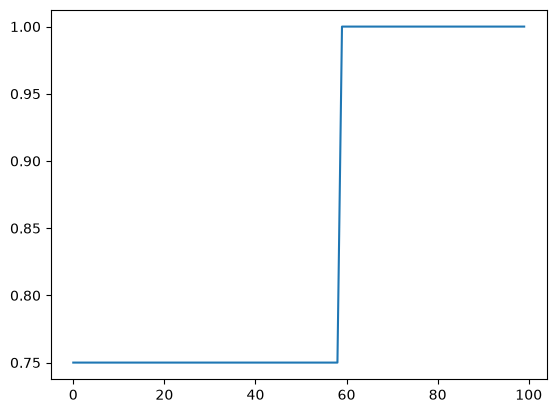

In [29]:
plt.plot(history.history['val_accuracy'])